# Data Visualization — การเลือกตั้ง ลำปาง\nใช้ข้อมูลจาก `cleaned/` folder

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# ── Thai font (สำหรับ macOS) ──
import matplotlib
matplotlib.rcParams['font.family'] = 'Tahoma'
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

CLEAN = Path('cleaned/')

results = pd.read_csv(CLEAN / 'master_results_cleaned.csv')
summary = pd.read_csv(CLEAN / 'master_summary_cleaned.csv')
coords  = pd.read_csv(CLEAN / 'coords_cleaned.csv')

r_in = results[(results['unit_number'] != -1)].copy()
r_bch = r_in[r_in['type'] == 'บช'].copy()
r_ket = r_in[r_in['type'] == 'เขต'].copy()
s_in  = summary[summary['unit_number'] != -1].copy()

print('Data loaded.')
print(f'  results ในเขต : {len(r_in):,} rows')
print(f'  summary ในเขต : {len(s_in):,} rows')
print(f'  coords        : {len(coords):,} rows')

Data loaded.
  results ในเขต : 19,083 rows
  summary ในเขต : 681 rows
  coords        : 342 rows


---
## 1. คะแนนรวมพรรค (บช) — Top 15

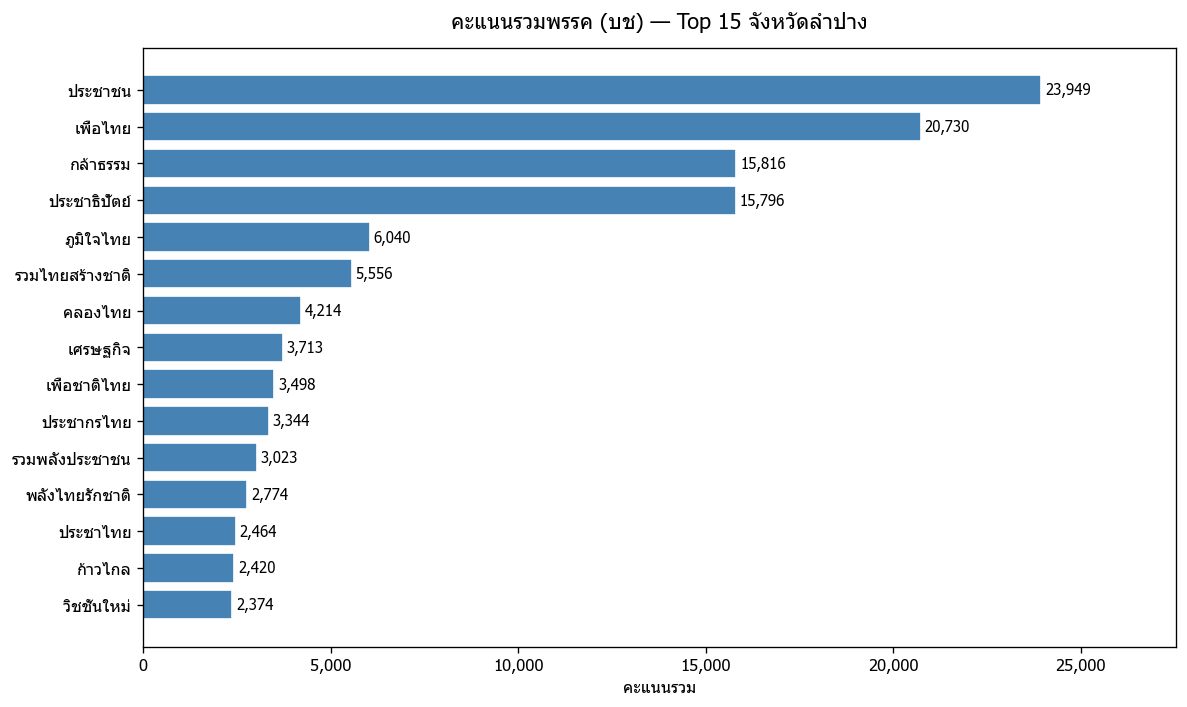

In [2]:
party_score = r_bch.groupby('name')['score'].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(party_score.index[::-1], party_score.values[::-1], color='steelblue', edgecolor='white')

for bar, val in zip(bars, party_score.values[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_title('คะแนนรวมพรรค (บช) — Top 15 จังหวัดลำปาง', fontsize=13, pad=12)
ax.set_xlabel('คะแนนรวม')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, party_score.max() * 1.15)
plt.tight_layout()
plt.show()

## 2. คะแนนผู้สมัคร ส.ส. เขต (เขต) — Top 20

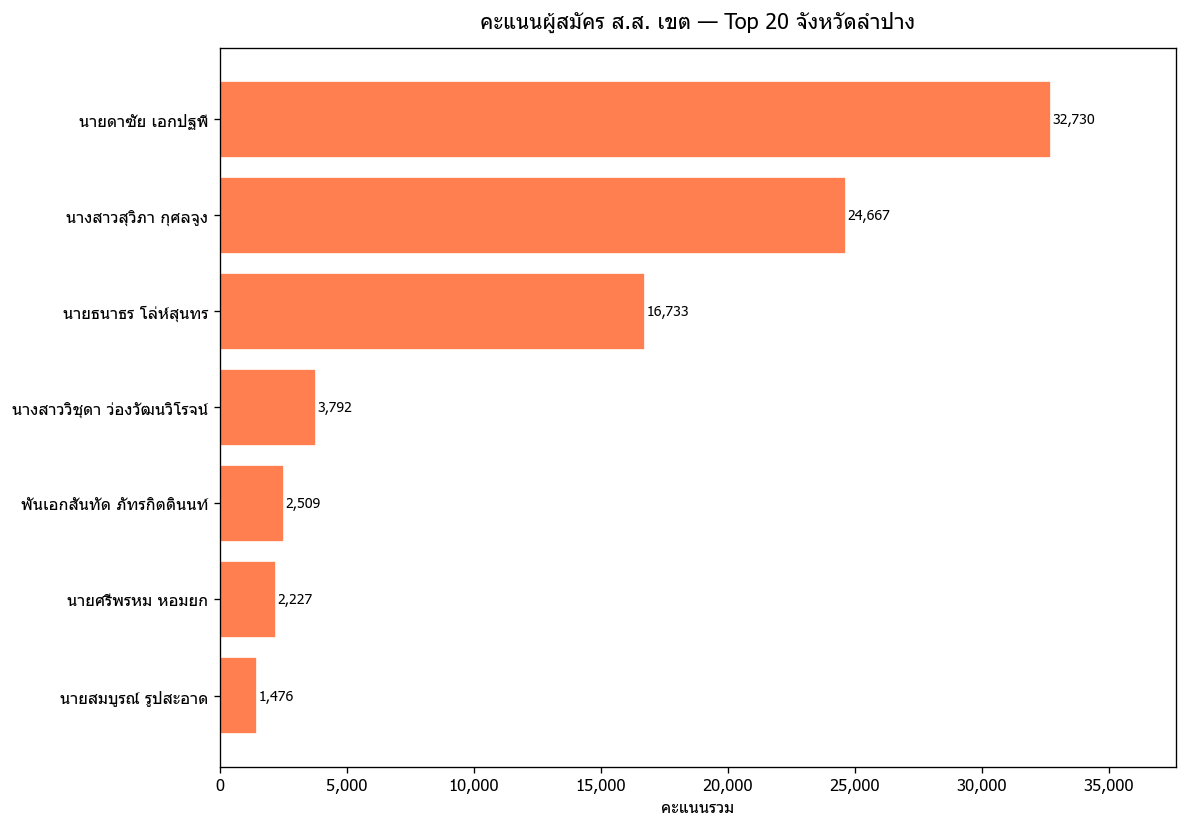

In [3]:
cand_score = r_ket.groupby('name')['score'].sum().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(cand_score.index[::-1], cand_score.values[::-1], color='coral', edgecolor='white')

for bar, val in zip(bars, cand_score.values[::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8.5)

ax.set_title('คะแนนผู้สมัคร ส.ส. เขต — Top 20 จังหวัดลำปาง', fontsize=13, pad=12)
ax.set_xlabel('คะแนนรวม')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, cand_score.max() * 1.15)
plt.tight_layout()
plt.show()

## 3. สัดส่วนบัตร (ดี / เสีย / งดออกเสียง) — ระดับจังหวัด

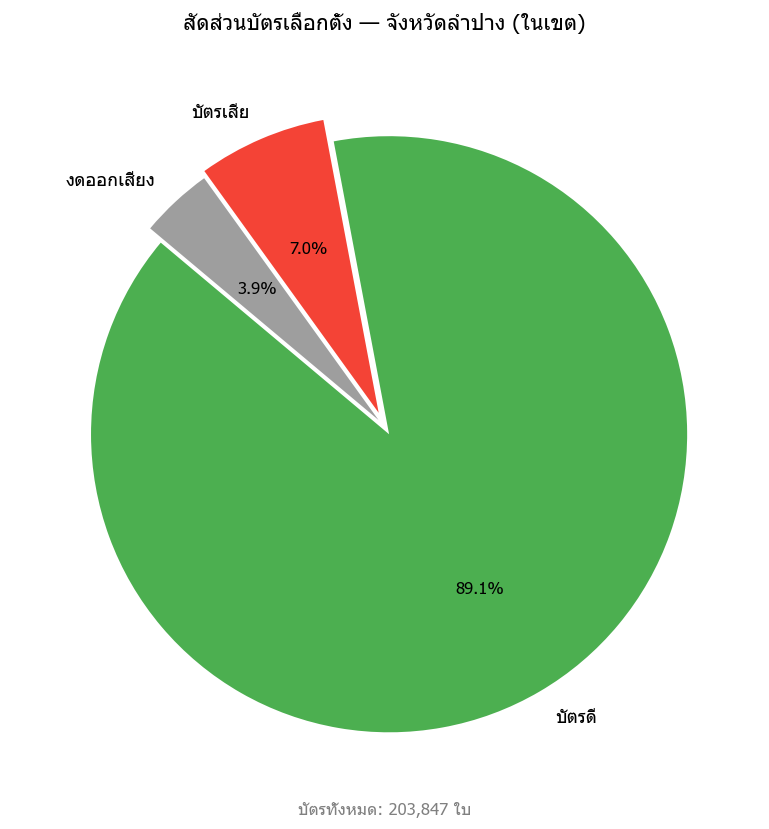

In [4]:
ballot_total = s_in[['valid_ballots','invalid_ballots','no_vote_ballots']].sum()
labels = ['บัตรดี', 'บัตรเสีย', 'งดออกเสียง']
colors = ['#4CAF50', '#F44336', '#9E9E9E']
explode = (0.03, 0.05, 0.03)

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    ballot_total, labels=labels, colors=colors, autopct='%1.1f%%',
    explode=explode, startangle=140, textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontsize(10)

ax.set_title('สัดส่วนบัตรเลือกตั้ง — จังหวัดลำปาง (ในเขต)', fontsize=13, pad=15)
total = int(ballot_total.sum())
ax.text(0, -1.3, f'บัตรทั้งหมด: {total:,} ใบ', ha='center', fontsize=10, color='gray')
plt.tight_layout()
plt.show()

## 4. บัตรเสีย (%) แยกอำเภอ

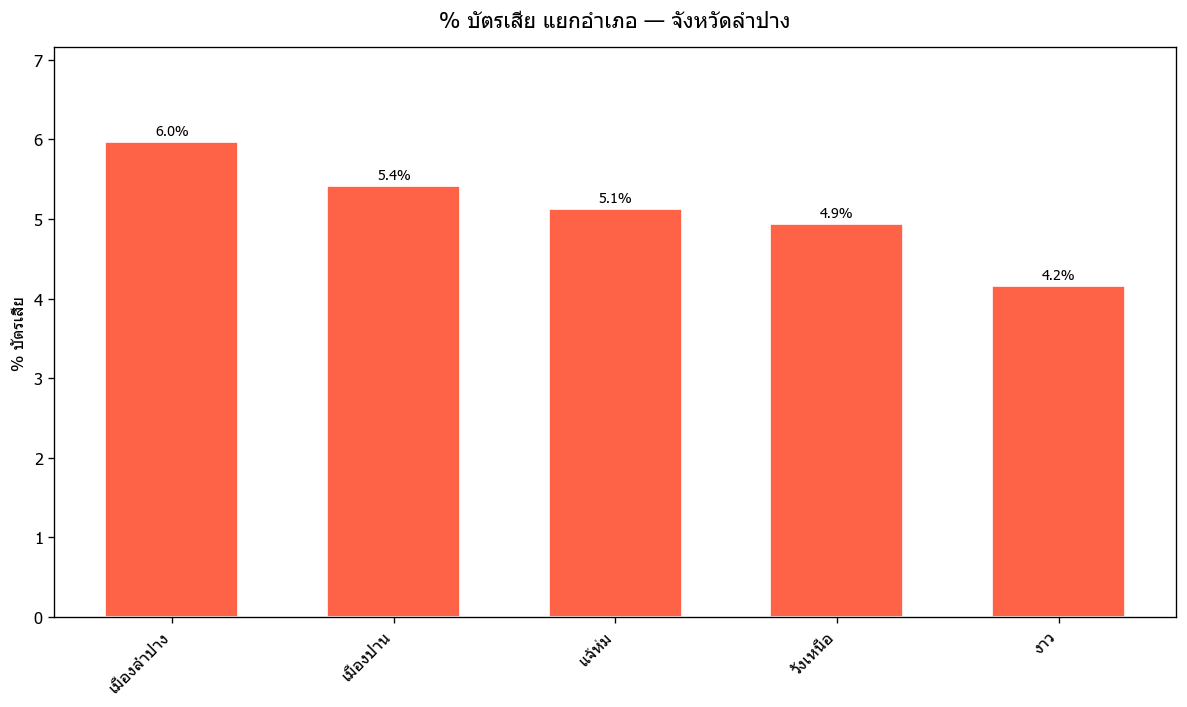

In [5]:
district_ballot = s_in.groupby('district')[['total_ballots','invalid_ballots']].sum()
district_ballot['invalid_pct'] = district_ballot['invalid_ballots'] / district_ballot['total_ballots'] * 100
district_ballot = district_ballot.sort_values('invalid_pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(district_ballot.index, district_ballot['invalid_pct'],
              color='tomato', edgecolor='white', width=0.6)

for bar, val in zip(bars, district_ballot['invalid_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8.5)

ax.set_title('% บัตรเสีย แยกอำเภอ — จังหวัดลำปาง', fontsize=13, pad=12)
ax.set_ylabel('% บัตรเสีย')
ax.set_ylim(0, district_ballot['invalid_pct'].max() * 1.2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. คะแนนพรรค Top 5 แยกอำเภอ (Stacked Bar)

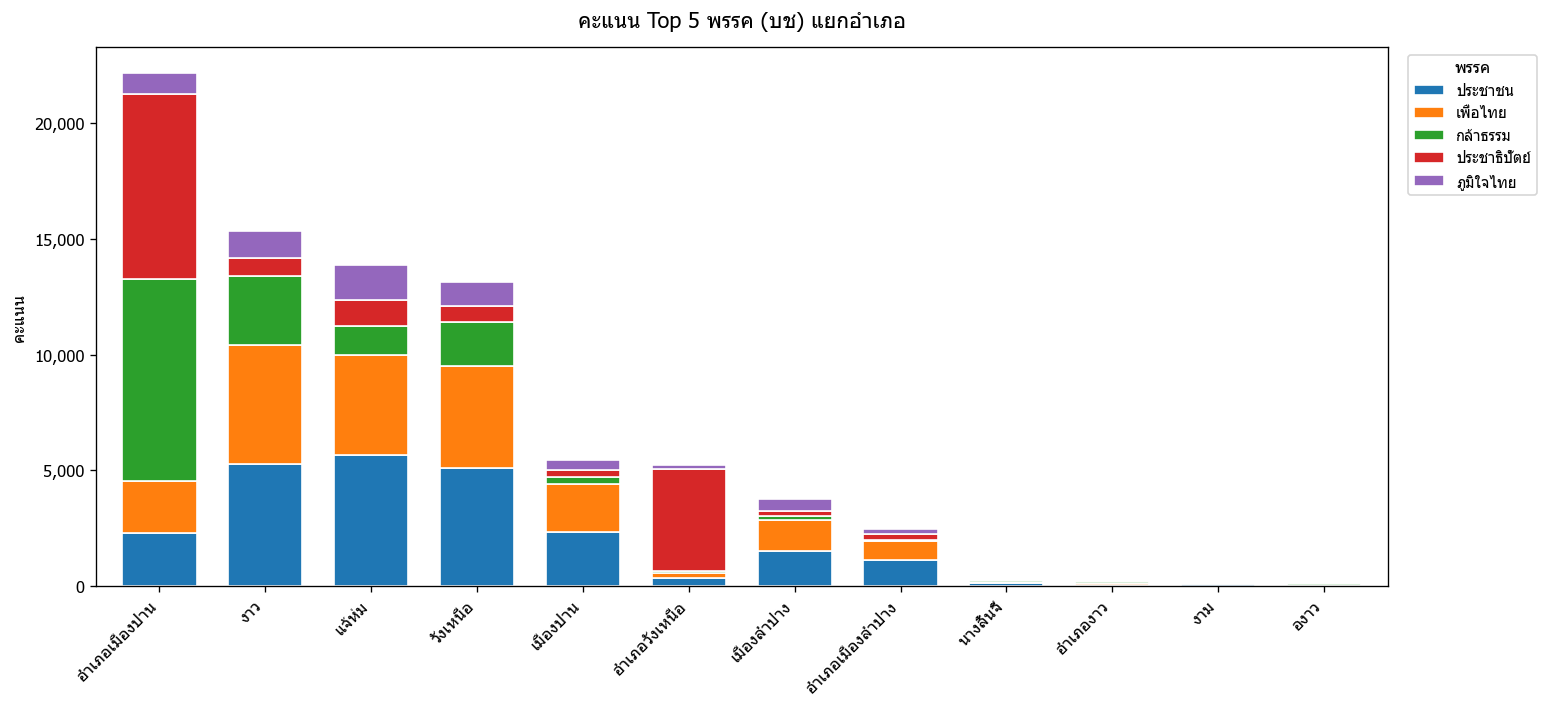

In [6]:
top5_parties = r_bch.groupby('name')['score'].sum().sort_values(ascending=False).head(5).index.tolist()

pivot = (
    r_bch[r_bch['name'].isin(top5_parties)]
    .groupby(['district','name'])['score'].sum()
    .unstack(fill_value=0)
)
pivot = pivot[top5_parties]  # เรียงลำดับ
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]  # sort by total

colors5 = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']

fig, ax = plt.subplots(figsize=(13, 6))
pivot.plot(kind='bar', stacked=True, ax=ax, color=colors5, edgecolor='white', width=0.7)

ax.set_title('คะแนน Top 5 พรรค (บช) แยกอำเภอ', fontsize=13, pad=12)
ax.set_xlabel('')
ax.set_ylabel('คะแนน')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='พรรค', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Turnout (% ผู้มาใช้สิทธิ) แยกอำเภอ

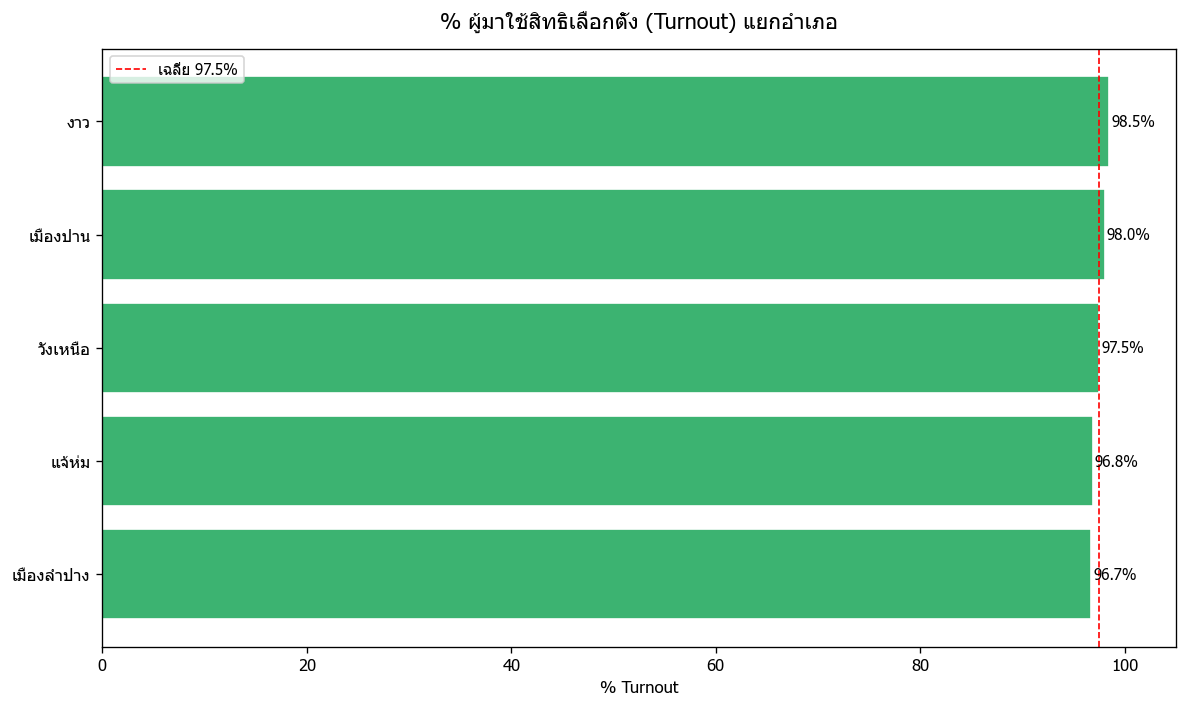

In [7]:
# ใช้ type=บช (บัญชีรายชื่อ) เพราะมีข้อมูลครบทุกอำเภอ
s_bch = s_in[s_in['type'] == 'บช'].groupby('district')[['total_ballots','valid_ballots','no_vote_ballots']].sum()
s_bch['voted'] = s_bch['total_ballots'] - s_bch['no_vote_ballots']
s_bch['turnout_pct'] = s_bch['voted'] / s_bch['total_ballots'] * 100
s_bch = s_bch.sort_values('turnout_pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(s_bch.index[::-1], s_bch['turnout_pct'][::-1],
               color='mediumseagreen', edgecolor='white')

for bar, val in zip(bars, s_bch['turnout_pct'][::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.axvline(s_bch['turnout_pct'].mean(), color='red', linestyle='--', linewidth=1, label=f'เฉลี่ย {s_bch["turnout_pct"].mean():.1f}%')
ax.set_title('% ผู้มาใช้สิทธิเลือกตั้ง (Turnout) แยกอำเภอ', fontsize=13, pad=12)
ax.set_xlabel('% Turnout')
ax.set_xlim(0, 105)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 7. Scatter: Turnout vs % บัตรเสีย (ระดับหน่วย)

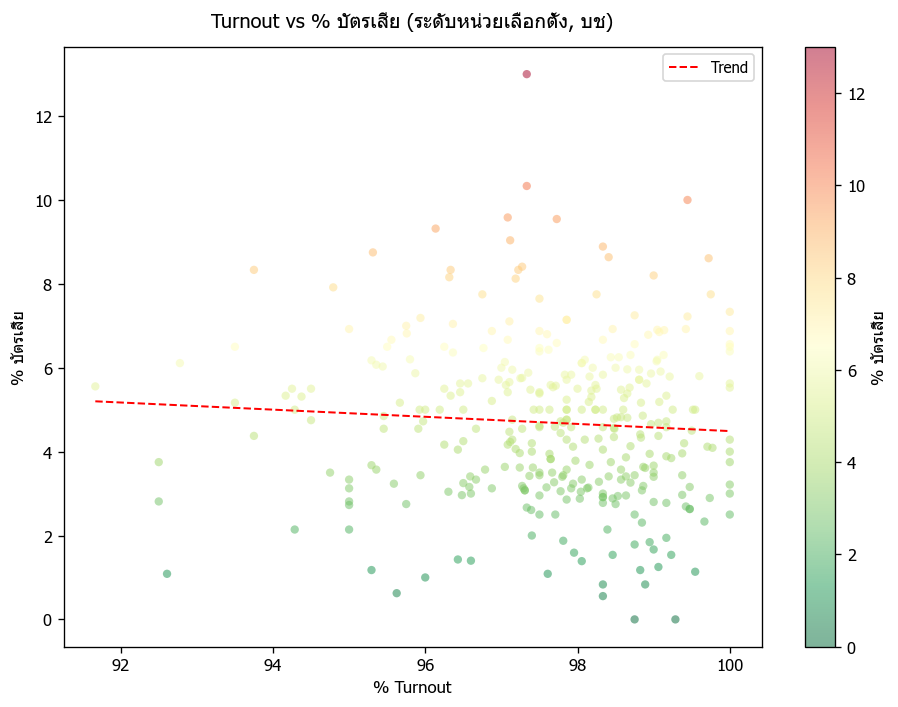

In [8]:
unit = s_in[s_in['type'] == 'บช'].copy()
unit['turnout_pct'] = (unit['total_ballots'] - unit['no_vote_ballots']) / unit['total_ballots'] * 100
unit['invalid_pct'] = unit['invalid_ballots'] / unit['total_ballots'] * 100

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(unit['turnout_pct'], unit['invalid_pct'],
                alpha=0.5, s=25, c=unit['invalid_pct'], cmap='RdYlGn_r', edgecolors='none')

# trend line
z = np.polyfit(unit['turnout_pct'].dropna(), unit['invalid_pct'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(unit['turnout_pct'].min(), unit['turnout_pct'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=1.2, label='Trend')

plt.colorbar(sc, ax=ax, label='% บัตรเสีย')
ax.set_title('Turnout vs % บัตรเสีย (ระดับหน่วยเลือกตั้ง, บช)', fontsize=12, pad=12)
ax.set_xlabel('% Turnout')
ax.set_ylabel('% บัตรเสีย')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8. Map — หน่วยเลือกตั้งบนแผนที่ (Scatter Map)

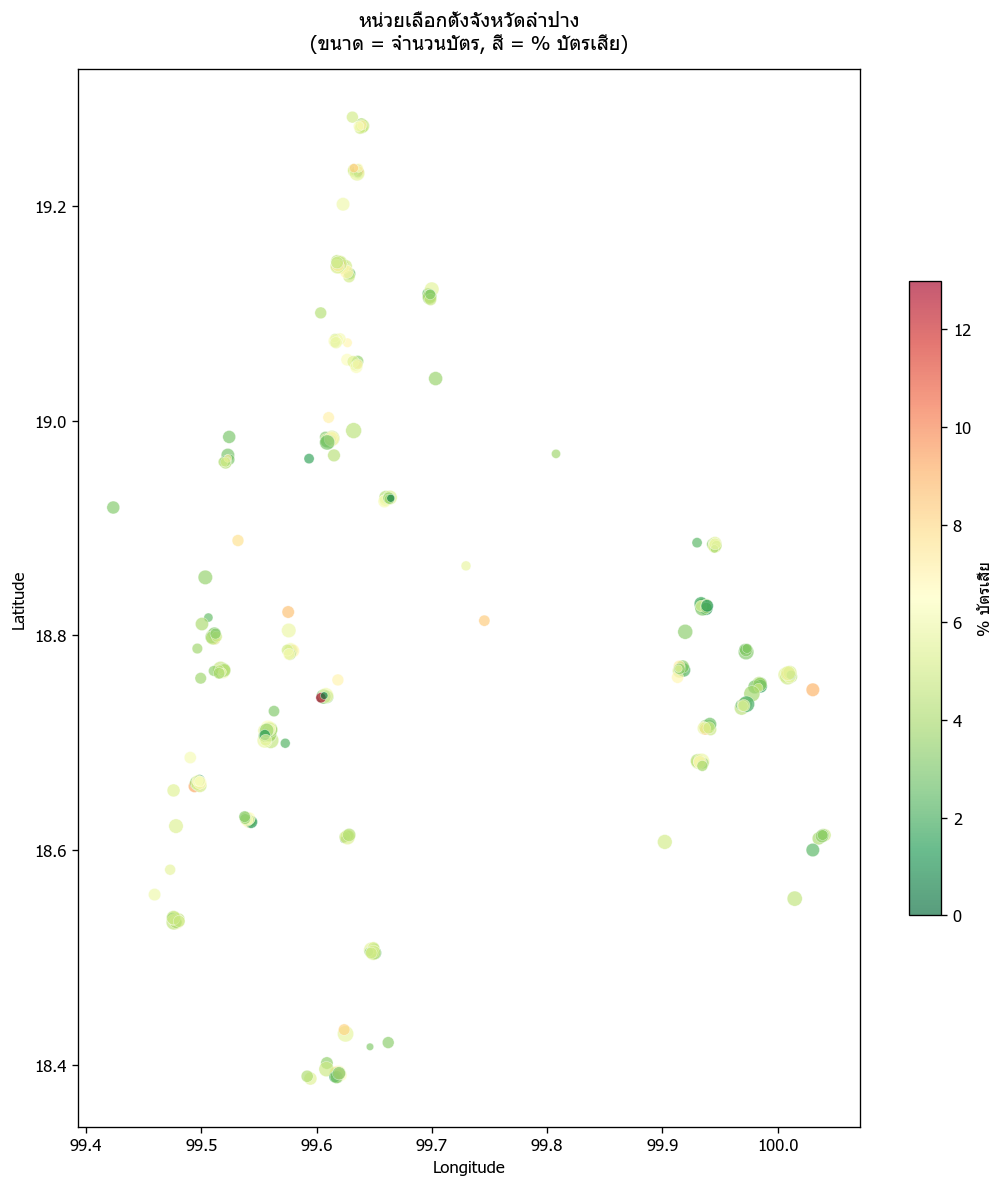

In [9]:
JOIN = ['district','sub-district','unit_number']
s_bch_unit = s_in[s_in['type']=='บช'][JOIN + ['total_ballots','valid_ballots','invalid_ballots']].copy()
map_df = s_bch_unit.merge(coords[JOIN + ['latitude','longitude']], on=JOIN, how='left')
map_df = map_df.dropna(subset=['latitude','longitude'])

# jitter เล็กน้อยเพื่อกระจายจุดซ้อนทับ
rng = np.random.default_rng(42)
map_df['lat_j'] = map_df['latitude']  + rng.uniform(-0.003, 0.003, len(map_df))
map_df['lon_j'] = map_df['longitude'] + rng.uniform(-0.003, 0.003, len(map_df))
map_df['invalid_pct'] = map_df['invalid_ballots'] / map_df['total_ballots'] * 100

fig, ax = plt.subplots(figsize=(9, 10))
sc = ax.scatter(
    map_df['lon_j'], map_df['lat_j'],
    c=map_df['invalid_pct'], cmap='RdYlGn_r',
    s=map_df['total_ballots'] / 8,  # ขนาด = จำนวนบัตร
    alpha=0.65, edgecolors='white', linewidths=0.3
)
plt.colorbar(sc, ax=ax, label='% บัตรเสีย', shrink=0.6)

ax.set_title('หน่วยเลือกตั้งจังหวัดลำปาง\n(ขนาด = จำนวนบัตร, สี = % บัตรเสีย)', fontsize=12, pad=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()